# Предобработка данных: лабораторная работа (Titanic)

**Датасет:** Titanic — данные о пассажирах (891 запись, 12 признаков)

**Задачи:**
1. Устранение пропусков в данных
2. Кодирование категориальных признаков
3. Нормализация числовых признаков
4. Масштабирование признаков (3 способа)
5. Обработка выбросов (удаление + замена)
6. Обработка нестандартного признака (Name → Title)
7. Отбор признаков (filter, wrapper, embedded)

In [1]:
%pip install numpy pandas matplotlib seaborn scipy scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder,
    StandardScaler, MinMaxScaler, RobustScaler
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    RFE, SelectFromModel
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Все библиотеки загружены успешно.')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Все библиотеки загружены успешно.


---
## 0. Загрузка датасета Titanic

Датасет содержит:
- **Числовые признаки:** Age (возраст), Fare (цена билета), SibSp (кол-во братьев/сестёр/супругов), Parch (кол-во родителей/детей)
- **Категориальные признаки:** Sex (пол), Embarked (порт посадки), Pclass (класс каюты)
- **Нестандартный признак:** Name (имя с титулом — Mr, Mrs, Miss и т.д.)
- **Пропуски:** Age (~10%), Fare (~8%), SibSp (~7%), Parch (~6%), Embarked (~9%), Sex (~5%), Pclass (~12%) — равномерное распределение 5–15%
- **Целевой признак:** Survived (0 = погиб, 1 = выжил)

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 891

def add_missing(arr, frac, seed=None):
    """Вносит пропуски в массив с заданной долей."""
    rng = np.random.default_rng(seed)
    result = arr.copy().astype(object)
    mask = rng.choice(len(arr), size=int(len(arr) * frac), replace=False)
    result[mask] = np.nan
    return result

# --- Базовые признаки (без пропусков) ---
pclass_vals  = np.random.choice([1,2,3], n, p=[0.24, 0.21, 0.55])
sex_vals     = np.random.choice(['male','female'], n, p=[0.65, 0.35])
age_vals     = np.random.normal(29.7, 14, n).clip(0.5, 80).round(1)
sibsp_vals   = np.random.choice([0,1,2,3,4,5], n, p=[0.68, 0.23, 0.05, 0.02, 0.01, 0.01]).astype(float)
parch_vals   = np.random.choice([0,1,2,3], n, p=[0.76, 0.13, 0.09, 0.02]).astype(float)
fare_vals    = np.where(pclass_vals==1, np.random.exponential(80, n),
               np.where(pclass_vals==2, np.random.exponential(20, n),
                        np.random.exponential(12, n))).round(4)
fare_vals[0:5] = [512, 480, 263, 263, 200]  # Выбросы в Fare

emb_vals     = np.random.choice(['S','C','Q'], n, p=[0.72, 0.19, 0.09])
cabin_vals   = np.array([f'{np.random.choice(["A","B","C","D","E","F"])}{np.random.randint(10,99)}'
                         for _ in range(n)])

titles = np.random.choice(['Mr','Mrs','Miss','Master','Dr','Rev'], n, p=[0.58,0.20,0.15,0.04,0.02,0.01])
surnames    = ['Smith','Jones','Brown','Williams','Taylor','Davies','Evans','Wilson']
first_names = ['John','Mary','James','Alice','Robert','Emma','William','Elizabeth']
names = [f'{np.random.choice(surnames)}, {t}. {np.random.choice(first_names)}' for t in titles]
ticket_pref = ['A/5 ','PC ','STON/O ','CA. ','W./C. ','']
tickets = [f'{np.random.choice(ticket_pref)}{np.random.randint(10000,99999)}' for _ in range(n)]

# --- Целевой признак ---
logit = (0.5*(sex_vals=='female').astype(float)
         - 0.3*(pclass_vals==3).astype(float)
         + 0.2*(pclass_vals==1).astype(float)
         - 0.01*age_vals)
prob = 1 / (1 + np.exp(-logit))
survived = (np.random.random(n) < prob).astype(int)

# --- Равномерные пропуски: 7 признаков, каждый 5–15% ---
# Числовые: Age 10%, Fare 8%, SibSp 7%, Parch 6%
# Категориальные: Sex 5%, Embarked 9%, Pclass 12%, Cabin 14%
age_miss     = add_missing(age_vals,   0.10, seed=1)
fare_miss    = add_missing(fare_vals,  0.08, seed=2)
sibsp_miss   = add_missing(sibsp_vals, 0.07, seed=3)
parch_miss   = add_missing(parch_vals, 0.06, seed=4)
sex_miss     = add_missing(sex_vals,   0.05, seed=5)
emb_miss     = add_missing(emb_vals,   0.09, seed=6)
pclass_miss  = add_missing(pclass_vals.astype(float), 0.12, seed=7)
cabin_miss   = add_missing(cabin_vals, 0.14, seed=8)

df = pd.DataFrame({
    'PassengerId': range(1, n+1),
    'Survived':   survived,
    'Pclass':     pclass_miss,
    'Name':       names,
    'Sex':        sex_miss,
    'Age':        age_miss,
    'SibSp':      sibsp_miss,
    'Parch':      parch_miss,
    'Ticket':     tickets,
    'Fare':       fare_miss,
    'Cabin':      cabin_miss,
    'Embarked':   emb_miss
})

# Приводим числовые колонки к float
for col in ['Age','Fare','SibSp','Parch','Pclass']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Сохраняем «чистые» базовые массивы для использования в задаче 7
pclass = pclass_vals
sex    = sex_vals

print(f'Размер датасета: {df.shape}')
print(f'\nТипы данных:')
print(df.dtypes)
print(f'\nРаспределение целевого признака:\n{df["Survived"].value_counts()}')
df.head(10)

Размер датасета: (891, 12)

Типы данных:
PassengerId      int64
Survived         int32
Pclass         float64
Name            object
Sex             object
Age            float64
SibSp          float64
Parch          float64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Распределение целевого признака:
Survived
0    492
1    399
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2.0,"Wilson, Mr. Emma",NaN,59.9,3.0,0.0,STON/O 62268,512.0000,B45,S
1,2,1,3.0,"Smith, Mr. James",female,21.2,NaN,0.0,W./C. 36998,480.0000,A73,S
2,3,0,3.0,"Taylor, Mr. William",male,40.1,0.0,0.0,STON/O 71339,263.0000,B57,C
3,4,1,NaN,"Brown, Mrs. Elizabeth",female,33.9,0.0,0.0,STON/O 74006,263.0000,A49,S
4,5,0,NaN,"Davies, Mr. Robert",male,47.9,0.0,2.0,57345,200.0000,A17,S
5,6,1,1.0,"Taylor, Mr. Robert",male,51.6,0.0,1.0,53826,58.8082,E65,S
6,7,0,1.0,"Williams, Mr. Alice",female,30.1,1.0,3.0,17443,46.4805,F40,S
7,8,0,3.0,"Wilson, Master. William",male,19.2,3.0,0.0,27084,1.4940,C67,NaN
8,9,0,3.0,"Taylor, Mr. William",male,36.1,0.0,2.0,PC 44361,9.0138,D57,C
9,10,1,3.0,"Smith, Mr. Robert",male,20.2,0.0,0.0,CA. 30529,1.6281,D92,S


Пропуски в данных:


,Кол-во пропусков,Доля (%)
Pclass,106,11.90
Sex,44,4.94
Age,89,9.99
SibSp,62,6.96
Parch,53,5.95
Fare,71,7.97
Cabin,124,13.92
Embarked,80,8.98


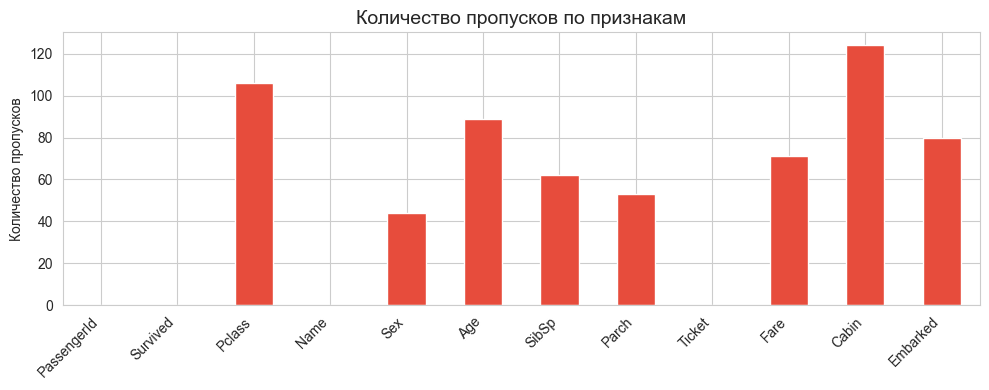

In [3]:
# Пропуски в данных
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_info = pd.DataFrame({'Кол-во пропусков': missing, 'Доля (%)': missing_pct})
missing_info = missing_info[missing_info['Кол-во пропусков'] > 0]
print('Пропуски в данных:')
display(missing_info)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in df.isnull().sum()]
df.isnull().sum().plot(kind='bar', ax=ax, color=colors)
ax.set_title('Количество пропусков по признакам', fontsize=14)
ax.set_ylabel('Количество пропусков')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 1. Устранение пропусков в данных

### 1.1 Удаление строк с пропусками (для демонстрации)

In [4]:
# Все признаки теперь имеют пропуски 5–15% — работаем со всеми
key_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Embarked', 'Cabin', 'Survived']
df_key = df[key_cols].copy()

df_dropped = df_key.dropna()
print(f'До удаления:    {df_key.shape[0]} строк')
print(f'После удаления: {df_dropped.shape[0]} строк')
print(f'Потеряно:       {df_key.shape[0] - df_dropped.shape[0]} строк ({(1 - df_dropped.shape[0]/df_key.shape[0])*100:.1f}%)')
print('\nВывод: потеря данных значительна, лучше использовать импьютацию.')

До удаления:    891 строк
После удаления: 430 строк
Потеряно:       461 строк (51.7%)

Вывод: потеря данных значительна, лучше использовать импьютацию.


### 1.2 Заполнение числовых признаков средним и медианой

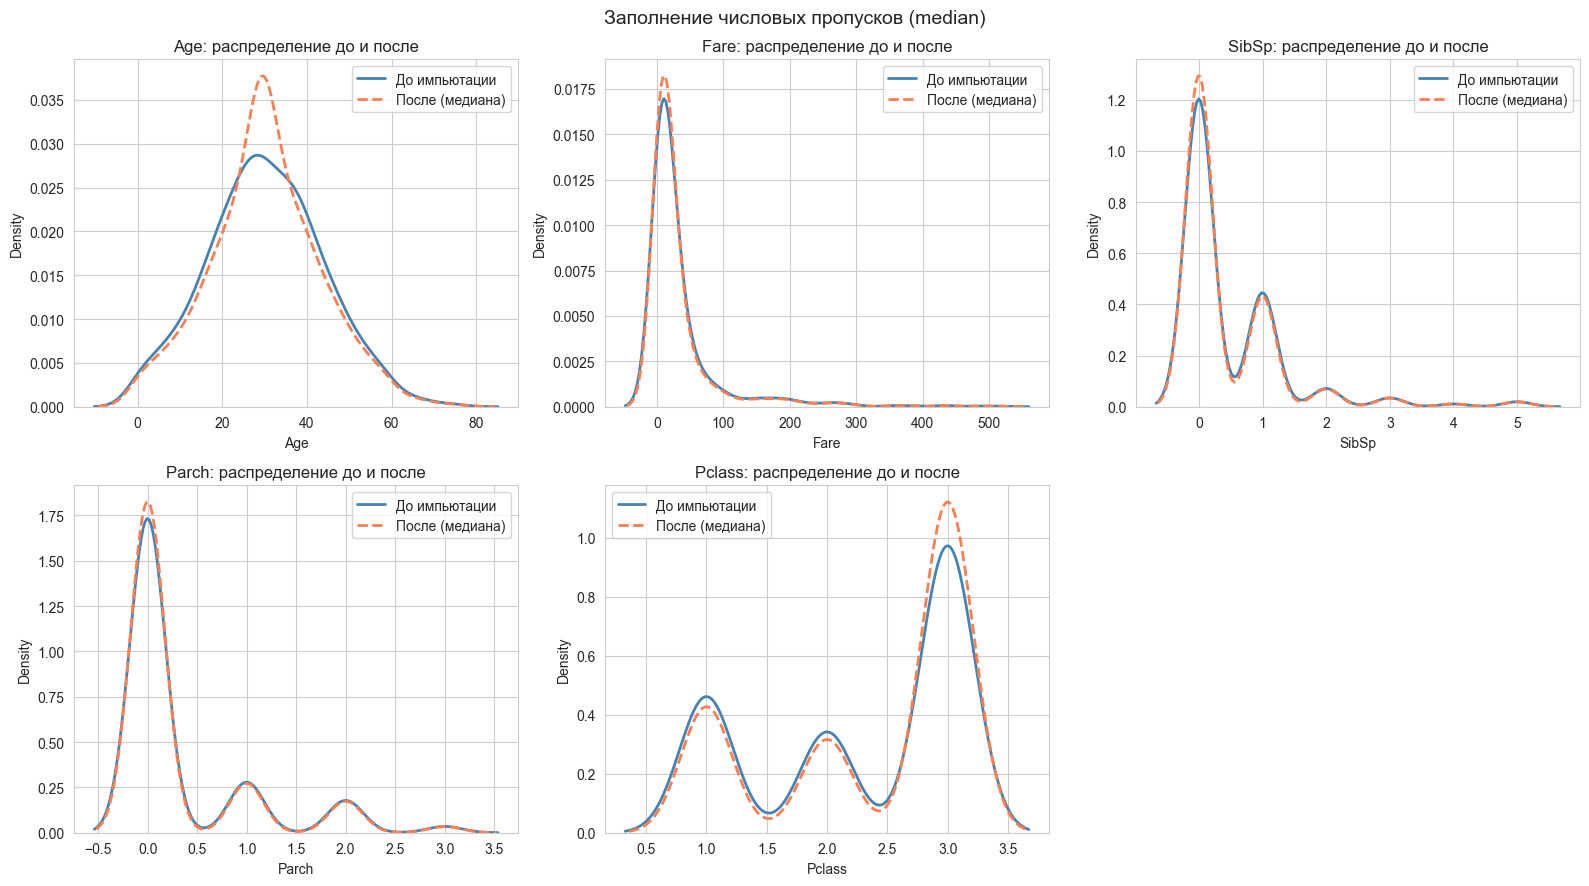

Оставшиеся пропуски (числовые): 0


In [5]:
df_imp = df_key.copy()
num_cols_with_na = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

# Age, SibSp, Parch, Pclass — медиана (целочисленные или слегка скошенные)
# Fare — медиана (экспоненциальное распределение, есть выбросы)
imp_median = SimpleImputer(strategy='median')
df_imp[num_cols_with_na] = imp_median.fit_transform(df_imp[num_cols_with_na])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), num_cols_with_na):
    sns.kdeplot(df_key[col].dropna(), ax=ax, label='До импьютации', linewidth=2, color='steelblue')
    sns.kdeplot(df_imp[col], ax=ax, label='После (медиана)', linewidth=2, linestyle='--', color='coral')
    ax.set_title(f'{col}: распределение до и после', fontsize=12)
    ax.legend()
axes.ravel()[-1].set_visible(False)  # скрываем пустой subplot
plt.suptitle('Заполнение числовых пропусков (median)', fontsize=14)
plt.tight_layout()
plt.show()

print('Оставшиеся пропуски (числовые):', df_imp[num_cols_with_na].isnull().sum().sum())

### 1.3 Заполнение числовых признаков методом KNN

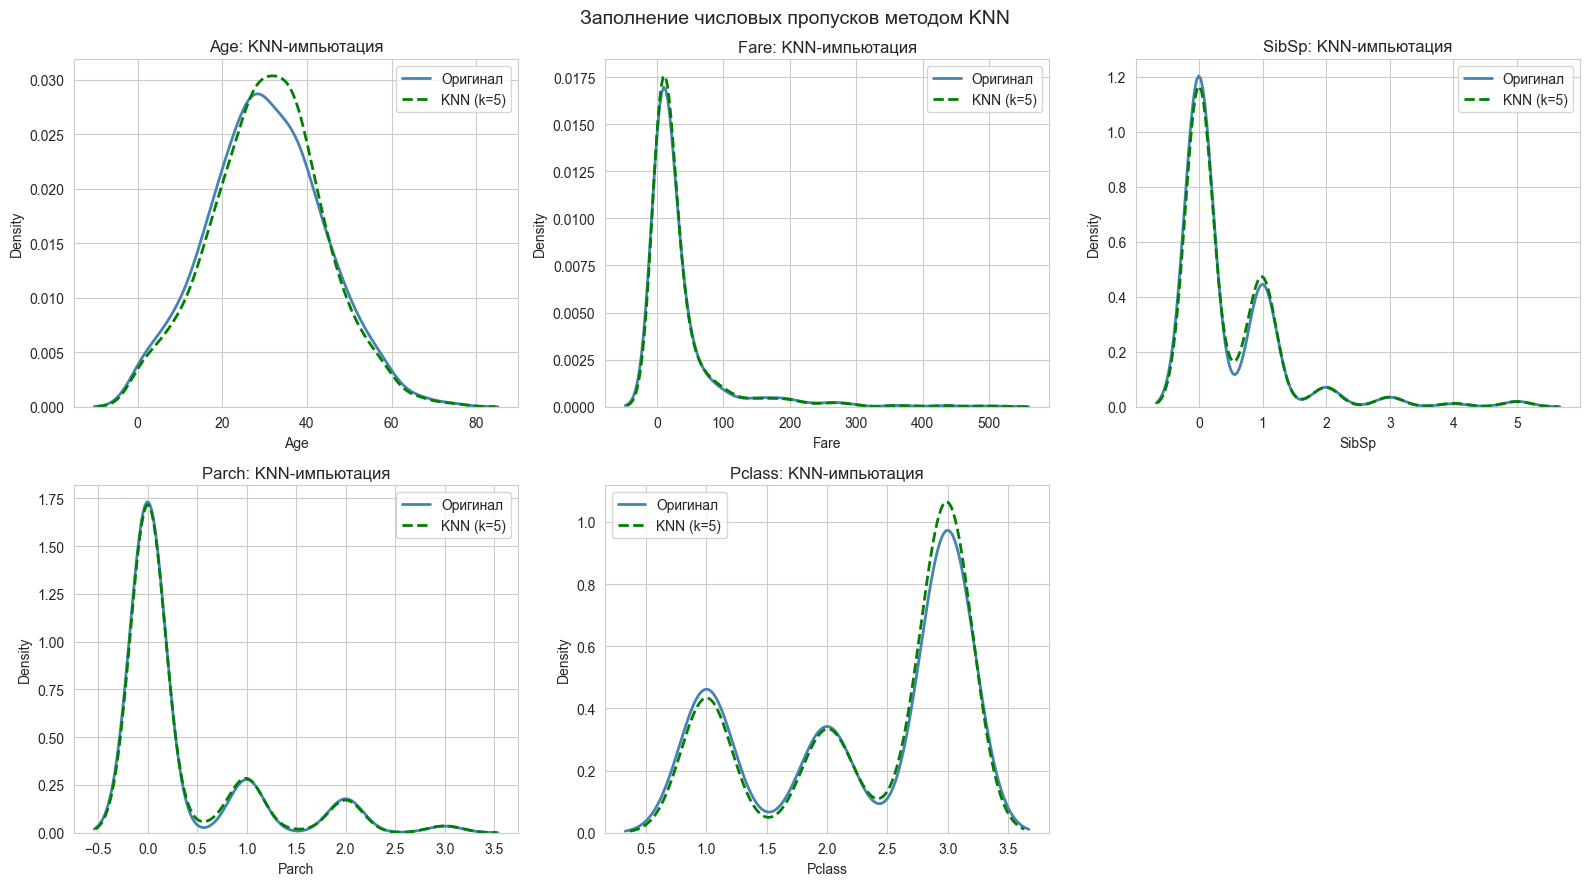

Оставшиеся пропуски (числовые): 0


In [6]:
df_knn = df_key.copy()

# KNN работает только с числовыми — применяем ко всем числовым с пропусками
num_knn_cols = ['Age','Fare','SibSp','Parch','Pclass']
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_knn[num_knn_cols] = knn_imputer.fit_transform(df_knn[num_knn_cols])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), num_knn_cols):
    sns.kdeplot(df_key[col].dropna(), ax=ax, label='Оригинал', linewidth=2, color='steelblue')
    sns.kdeplot(df_knn[col], ax=ax, label='KNN (k=5)', linewidth=2, linestyle='--', color='green')
    ax.set_title(f'{col}: KNN-импьютация', fontsize=12)
    ax.legend()
axes.ravel()[-1].set_visible(False)
plt.suptitle('Заполнение числовых пропусков методом KNN', fontsize=14)
plt.tight_layout()
plt.show()

print('Оставшиеся пропуски (числовые):', df_knn[num_knn_cols].isnull().sum().sum())

### 1.4 Заполнение категориальных признаков модой

До импьютации:
  Sex: 44 пропусков (4.9%)
  Embarked: 80 пропусков (9.0%)
  Cabin: 124 пропусков (13.9%)

После импьютации (мода):
  Sex: 0 пропусков
  Embarked: 0 пропусков
  Cabin: 0 пропусков


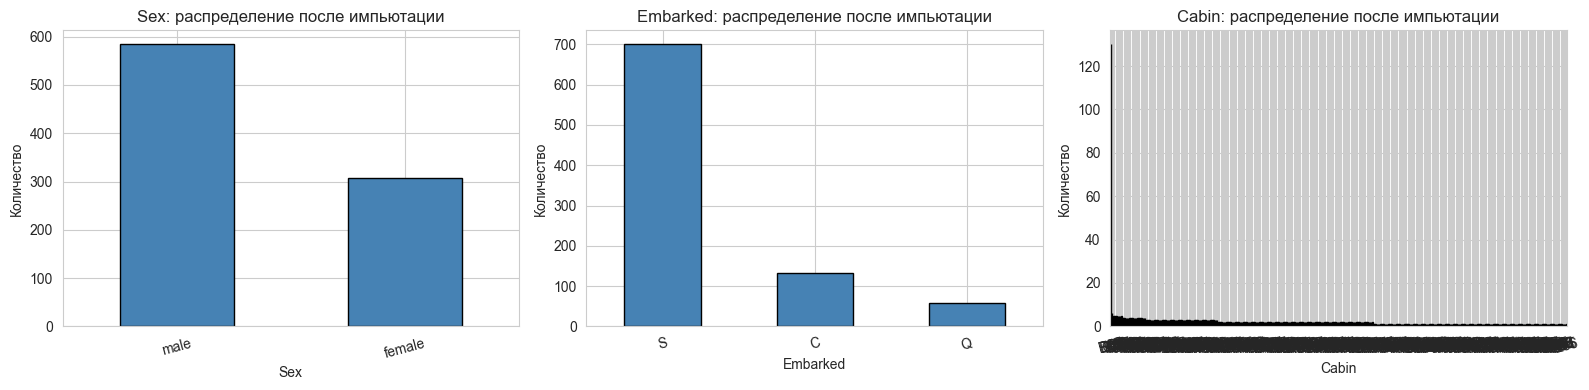


Итого пропусков в датасете: 0


In [7]:
cat_cols_with_na = ['Sex', 'Embarked', 'Cabin']

print('До импьютации:')
for col in cat_cols_with_na:
    print(f'  {col}: {df_imp[col].isnull().sum()} пропусков ({df_imp[col].isnull().mean()*100:.1f}%)')

imp_mode = SimpleImputer(strategy='most_frequent')
df_imp[cat_cols_with_na] = imp_mode.fit_transform(df_imp[cat_cols_with_na])

print('\nПосле импьютации (мода):')
for col in cat_cols_with_na:
    print(f'  {col}: {df_imp[col].isnull().sum()} пропусков')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols_with_na):
    pd.Series(df_imp[col]).value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{col}: распределение после импьютации', fontsize=12)
    ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print(f'\nИтого пропусков в датасете: {df_imp.isnull().sum().sum()}')

---
## 2. Кодирование категориальных признаков

Работаем с датасетом после устранения пропусков (`df_imp`).

In [8]:
df_enc = df_imp.copy()
cat_cols = ['Sex', 'Embarked', 'Pclass', 'Cabin']
print('Категориальные признаки и их уникальные значения:')
for col in cat_cols:
    print(f'  {col}: {sorted(df_enc[col].dropna().unique())}')

Категориальные признаки и их уникальные значения:
  Sex: ['female', 'male']
  Embarked: ['C', 'Q', 'S']
  Pclass: [1.0, 2.0, 3.0]
  Cabin: ['A12', 'A13', 'A14', 'A16', 'A17', 'A18', 'A22', 'A25', 'A26', 'A27', 'A29', 'A30', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A39', 'A40', 'A41', 'A43', 'A45', 'A46', 'A47', 'A48', 'A49', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A61', 'A62', 'A63', 'A65', 'A66', 'A67', 'A68', 'A69', 'A70', 'A71', 'A72', 'A73', 'A74', 'A76', 'A77', 'A80', 'A81', 'A83', 'A86', 'A87', 'A88', 'A89', 'A90', 'A91', 'A92', 'A93', 'A95', 'A97', 'A98', 'B11', 'B12', 'B13', 'B14', 'B16', 'B17', 'B18', 'B20', 'B21', 'B22', 'B23', 'B24', 'B25', 'B26', 'B27', 'B28', 'B29', 'B30', 'B32', 'B33', 'B34', 'B35', 'B36', 'B37', 'B39', 'B41', 'B42', 'B45', 'B46', 'B47', 'B48', 'B49', 'B51', 'B52', 'B53', 'B55', 'B56', 'B57', 'B58', 'B60', 'B61', 'B62', 'B64', 'B68', 'B69', 'B70', 'B72', 'B74', 'B75', 'B76', 'B77', 'B78', 'B79', 'B81', 'B82', 'B85', 'B86', 'B87', 'B88',

### 2.1 Label Encoding (Sex — бинарный признак)

In [9]:
le = LabelEncoder()
df_enc['Sex_le'] = le.fit_transform(df_enc['Sex'])

print('Label Encoding для Sex:')
print(f'  Классы: {le.classes_}')
print(f'  Коды:   {le.transform(le.classes_)}')
display(df_enc[['Sex', 'Sex_le']].drop_duplicates().reset_index(drop=True))

Label Encoding для Sex:
  Классы: ['female' 'male']
  Коды:   [0 1]


,Sex,Sex_le
0,male,1
1,female,0


### 2.2 Ordinal Encoding (Pclass — есть естественный порядок: 1-й > 2-й > 3-й класс)

In [10]:
oe = OrdinalEncoder(categories=[[1, 2, 3]])
df_enc['Pclass_ord'] = oe.fit_transform(df_enc[['Pclass']])

print('Ordinal Encoding для Pclass (1-й = высший класс):')
display(df_enc[['Pclass', 'Pclass_ord']].drop_duplicates().sort_values('Pclass_ord').reset_index(drop=True))

Ordinal Encoding для Pclass (1-й = высший класс):


,Pclass,Pclass_ord
0,1.0,0.0
1,2.0,1.0
2,3.0,2.0


### 2.3 One-Hot Encoding (Embarked — нет естественного порядка)

In [11]:
df_enc = pd.get_dummies(df_enc, columns=['Embarked'], prefix='Emb', drop_first=False)

ohe_cols = [c for c in df_enc.columns if c.startswith('Emb_')]
print(f'Новые OHE-столбцы: {ohe_cols}')
display(df_enc[ohe_cols].head(10))

Новые OHE-столбцы: ['Emb_C', 'Emb_Q', 'Emb_S']


,Emb_C,Emb_Q,Emb_S
0,False,False,True
1,False,False,True
2,True,False,False
3,False,False,True
4,False,False,True
5,False,False,True
6,False,False,True
7,False,False,True
8,True,False,False
9,False,False,True


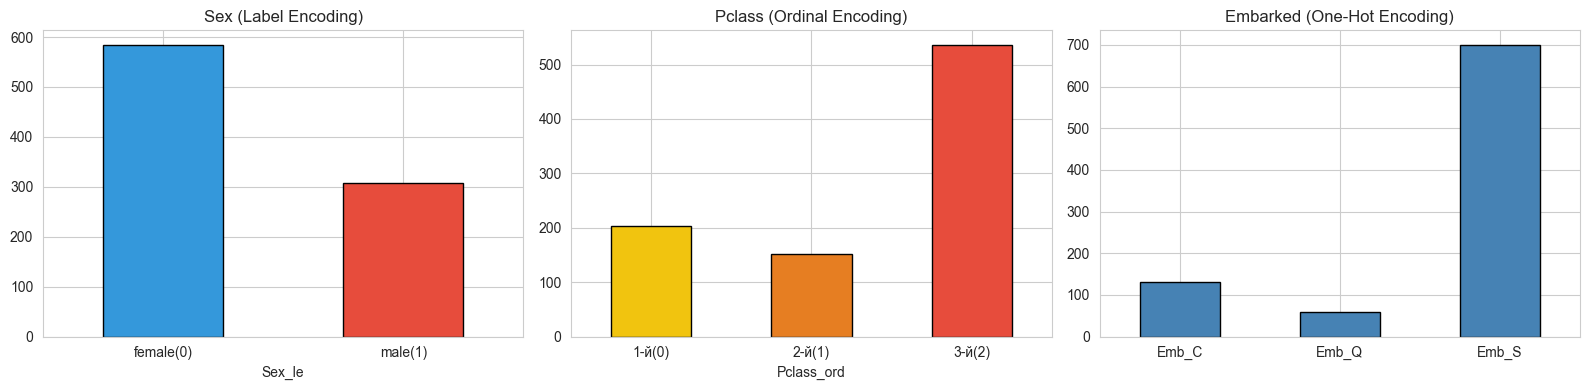

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_enc['Sex_le'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#3498db','#e74c3c'], edgecolor='black')
axes[0].set_title('Sex (Label Encoding)', fontsize=12)
axes[0].set_xticklabels(['female(0)', 'male(1)'], rotation=0)

df_enc['Pclass_ord'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color=['#f1c40f','#e67e22','#e74c3c'], edgecolor='black')
axes[1].set_title('Pclass (Ordinal Encoding)', fontsize=12)
axes[1].set_xticklabels(['1-й(0)','2-й(1)','3-й(2)'], rotation=0)

df_enc[ohe_cols].sum().plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_title('Embarked (One-Hot Encoding)', fontsize=12)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 3. Нормализация числовых признаков

Применим различные преобразования к `Fare` — сильно скошенное распределение (экспоненциальное).

=== Исходное распределение Fare ===


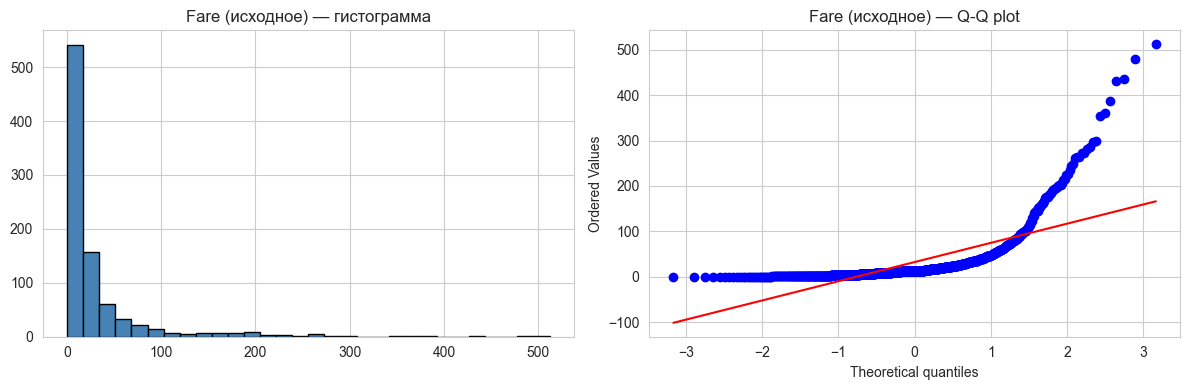

  Shapiro-Wilk: W=0.5287, p=0.000000 — НЕ нормальное


In [13]:
def diagnostic_plots(series, title):
    """Гистограмма + Q-Q plot"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    series.hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title(f'{title} — гистограмма', fontsize=12)
    stats.probplot(series.dropna(), dist='norm', plot=axes[1])
    axes[1].set_title(f'{title} — Q-Q plot', fontsize=12)
    plt.tight_layout()
    plt.show()
    sample = series.dropna().sample(min(len(series.dropna()), 500), random_state=42)
    stat, p_val = stats.shapiro(sample)
    print(f'  Shapiro-Wilk: W={stat:.4f}, p={p_val:.6f} — {"нормальное" if p_val > 0.05 else "НЕ нормальное"}')

fare_clean = df_imp['Fare'].copy()
# Fare должен быть > 0 для log-преобразования
fare_clean = fare_clean.clip(lower=0.1)

print('=== Исходное распределение Fare ===')
diagnostic_plots(fare_clean, 'Fare (исходное)')

=== Логарифмическое преобразование ===


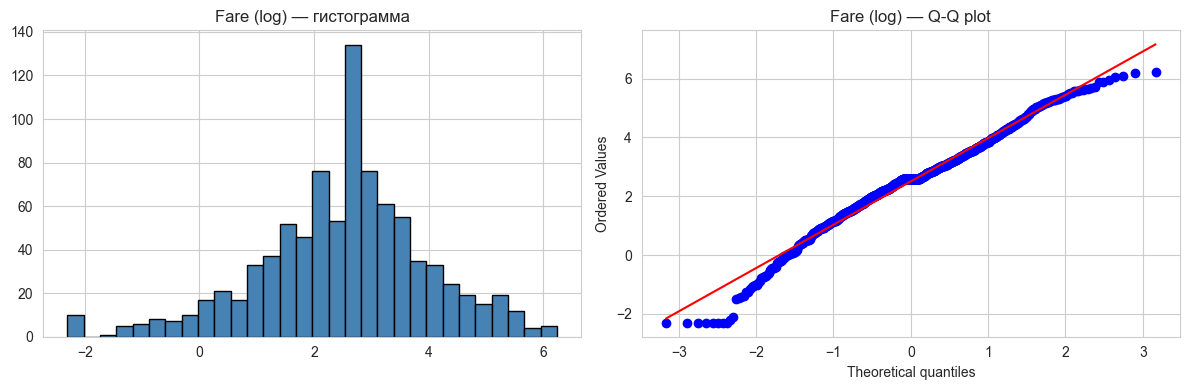

  Shapiro-Wilk: W=0.9849, p=0.000046 — НЕ нормальное


In [14]:
print('=== Логарифмическое преобразование ===')
fare_log = np.log(fare_clean)
diagnostic_plots(fare_log, 'Fare (log)')

=== Квадратный корень ===


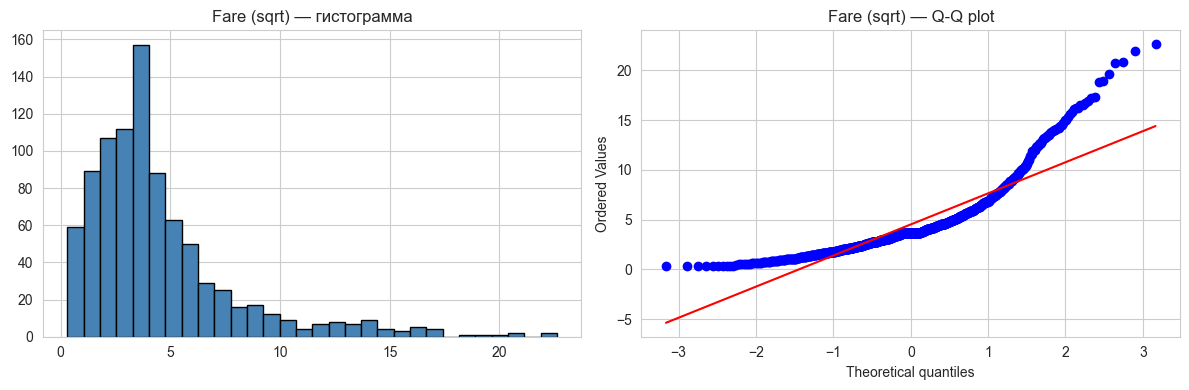

  Shapiro-Wilk: W=0.8071, p=0.000000 — НЕ нормальное


In [15]:
print('=== Квадратный корень ===')
fare_sqrt = np.sqrt(fare_clean)
diagnostic_plots(fare_sqrt, 'Fare (sqrt)')

=== Преобразование Бокса-Кокса ===
  Оптимальное λ = 0.0740


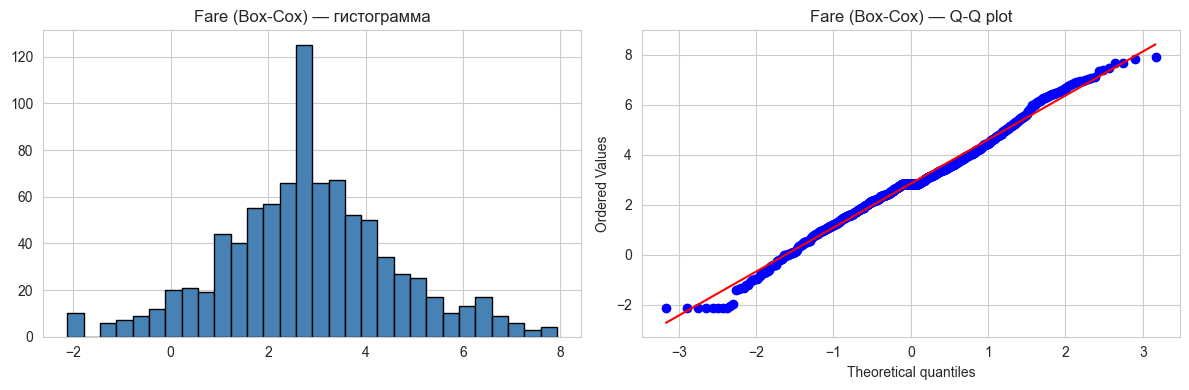

  Shapiro-Wilk: W=0.9888, p=0.000728 — НЕ нормальное


In [16]:
print('=== Преобразование Бокса-Кокса ===')
fare_boxcox, lam = stats.boxcox(fare_clean)
print(f'  Оптимальное λ = {lam:.4f}')
diagnostic_plots(pd.Series(fare_boxcox), 'Fare (Box-Cox)')

=== Преобразование Йео-Джонсона ===
  Оптимальное λ = -0.0770


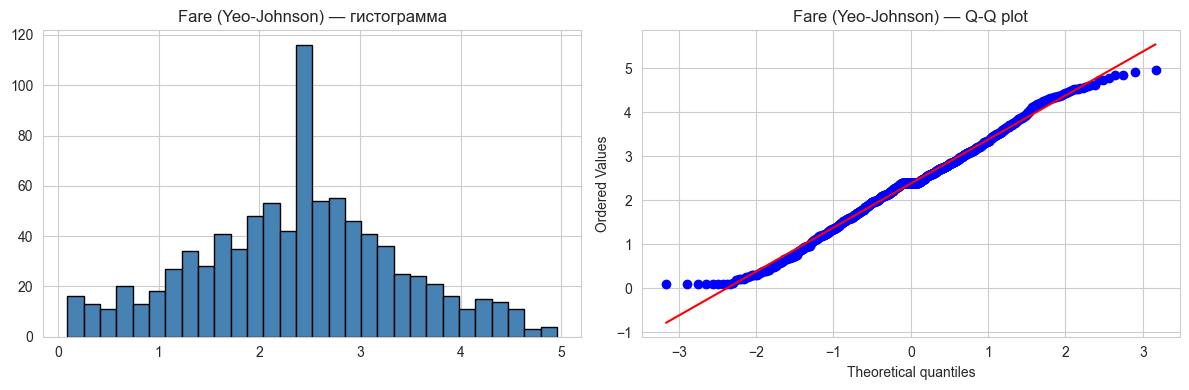

  Shapiro-Wilk: W=0.9901, p=0.001967 — НЕ нормальное


In [17]:
print('=== Преобразование Йео-Джонсона ===')
fare_yj, lam_yj = stats.yeojohnson(fare_clean)
print(f'  Оптимальное λ = {lam_yj:.4f}')
diagnostic_plots(pd.Series(fare_yj), 'Fare (Yeo-Johnson)')

In [18]:
transforms = {
    'Исходное': fare_clean,
    'Log': fare_log,
    'Sqrt': fare_sqrt,
    'Box-Cox': pd.Series(fare_boxcox),
    'Yeo-Johnson': pd.Series(fare_yj)
}

results = []
for name, s in transforms.items():
    sample = s.dropna().sample(min(len(s.dropna()), 500), random_state=42)
    w, p = stats.shapiro(sample)
    results.append({'Преобразование': name, 'Skewness': s.skew(),
                    'Kurtosis': s.kurtosis(), 'Shapiro W': w, 'Shapiro p': p})

results_df = pd.DataFrame(results).set_index('Преобразование')
print('Сравнение методов нормализации для Fare:')
display(results_df.style.highlight_max(subset=['Shapiro p'], color='lightgreen')
        .format({'Skewness': '{:.4f}', 'Kurtosis': '{:.4f}',
                 'Shapiro W': '{:.4f}', 'Shapiro p': '{:.6f}'}))

Сравнение методов нормализации для Fare:


,Skewness,Kurtosis,Shapiro W,Shapiro p
Преобразование,,,,
Исходное,4.0114,19.9546,0.5287,0.000000
Log,-0.3949,0.7474,0.9849,0.000046
Sqrt,1.9986,4.8814,0.8071,0.000000
Box-Cox,0.0153,0.4168,0.9888,0.000728
Yeo-Johnson,0.0066,-0.2036,0.9901,0.001967


---
## 4. Масштабирование признаков (три способа)

Масштабируем числовые признаки:
1. **StandardScaler** (Z-оценка)
2. **MinMaxScaler**
3. **RobustScaler** (по медиане и IQR)

In [19]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
X_num = df_imp[num_cols].copy()

print('Статистики ДО масштабирования:')
display(X_num.describe().round(2))

Статистики ДО масштабирования:


,Age,Fare,SibSp,Parch
count,891.00,891.00,891.00,891.00
mean,30.18,32.33,0.43,0.31
std,12.95,58.71,0.84,0.67
min,0.50,0.00,0.00,0.00
25%,22.10,5.33,0.00,0.00
50%,29.80,13.23,0.00,0.00
75%,38.00,29.28,1.00,0.00
max,74.40,512.00,5.00,3.00



=== StandardScaler (Z-оценка) ===


,Age,Fare,SibSp,Parch
count,712.000,712.000,712.000,712.000
mean,0.000,0.000,0.000,0.000
std,1.001,1.001,1.001,1.001
min,-2.336,-0.539,-0.511,-0.458
25%,-0.600,-0.447,-0.511,-0.458
50%,-0.032,-0.316,-0.511,-0.458
75%,0.605,-0.056,0.670,-0.458
max,3.476,8.097,5.393,3.869



=== MinMaxScaler [0,1] ===


,Age,Fare,SibSp,Parch
count,712.000,712.000,712.000,712.000
mean,0.402,0.062,0.087,0.106
std,0.172,0.116,0.170,0.231
min,0.000,0.000,0.000,0.000
25%,0.299,0.011,0.000,0.000
50%,0.396,0.026,0.000,0.000
75%,0.506,0.056,0.200,0.000
max,1.000,1.000,1.000,1.000



=== RobustScaler (медиана/IQR) ===


,Age,Fare,SibSp,Parch
count,712.000,712.000,712.000,712.000
mean,0.026,0.808,0.433,0.317
std,0.830,2.560,0.848,0.694
min,-1.912,-0.570,0.000,0.000
25%,-0.471,-0.334,0.000,0.000
50%,0.000,0.000,0.000,0.000
75%,0.529,0.666,1.000,0.000
max,2.910,21.523,5.000,3.000


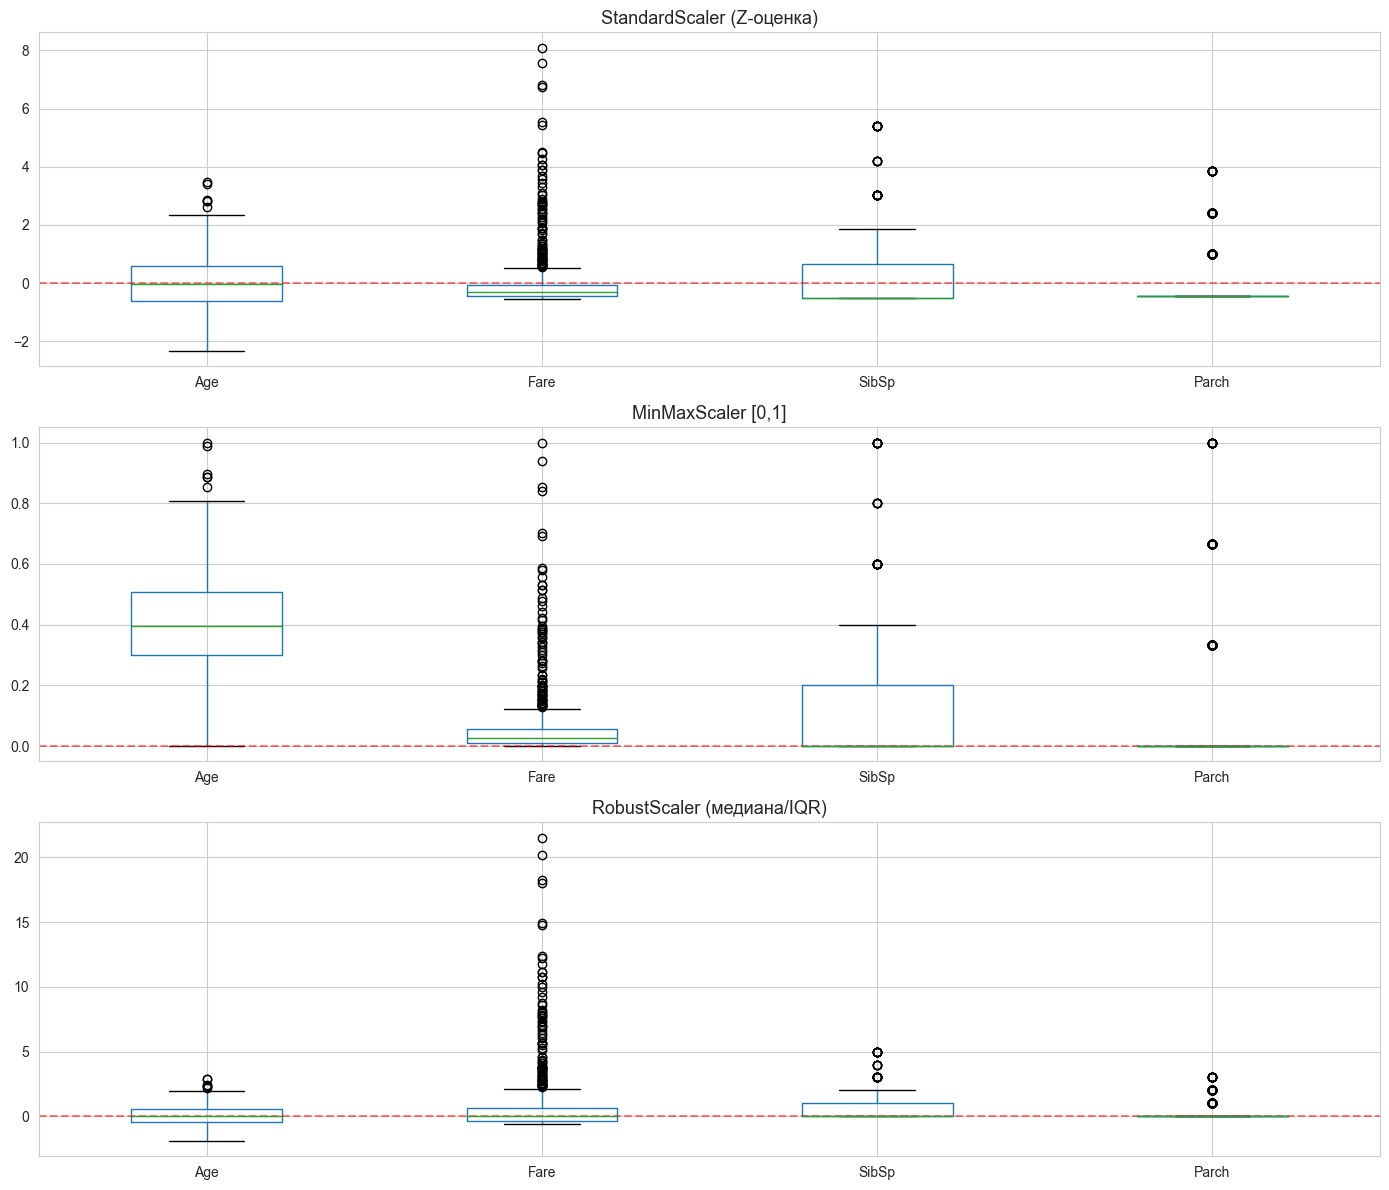

In [20]:
X_train_num, X_test_num = train_test_split(X_num, test_size=0.2, random_state=42)

scalers = {
    'StandardScaler (Z-оценка)': StandardScaler(),
    'MinMaxScaler [0,1]': MinMaxScaler(),
    'RobustScaler (медиана/IQR)': RobustScaler()
}

fig, axes = plt.subplots(len(scalers), 1, figsize=(14, 4 * len(scalers)))

for idx, (name, scaler) in enumerate(scalers.items()):
    scaler.fit(X_train_num)
    X_scaled = pd.DataFrame(scaler.transform(X_train_num), columns=num_cols)
    print(f'\n=== {name} ===')
    display(X_scaled.describe().round(3))
    X_scaled.boxplot(ax=axes[idx], vert=True)
    axes[idx].set_title(name, fontsize=13)
    axes[idx].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

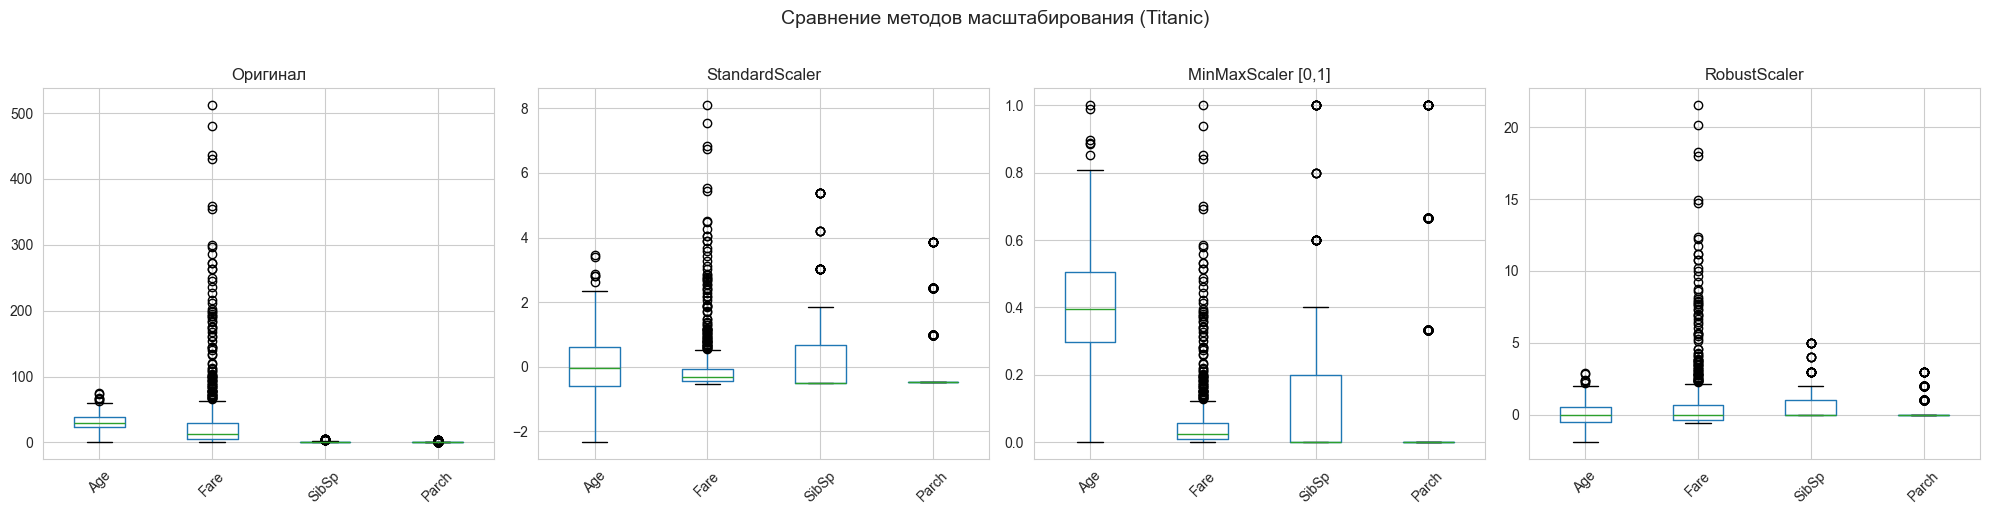

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

X_train_num.boxplot(ax=axes[0])
axes[0].set_title('Оригинал', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

for idx, (name, scaler) in enumerate(scalers.items()):
    scaler.fit(X_train_num)
    X_s = pd.DataFrame(scaler.transform(X_train_num), columns=num_cols)
    X_s.boxplot(ax=axes[idx+1])
    axes[idx+1].set_title(name.split('(')[0].strip(), fontsize=12)
    axes[idx+1].tick_params(axis='x', rotation=45)

plt.suptitle('Сравнение методов масштабирования (Titanic)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Обработка выбросов

### 5.1 Обнаружение выбросов методом IQR


Fare: нижняя граница=-30.6, верхняя граница=65.2, выбросов=106


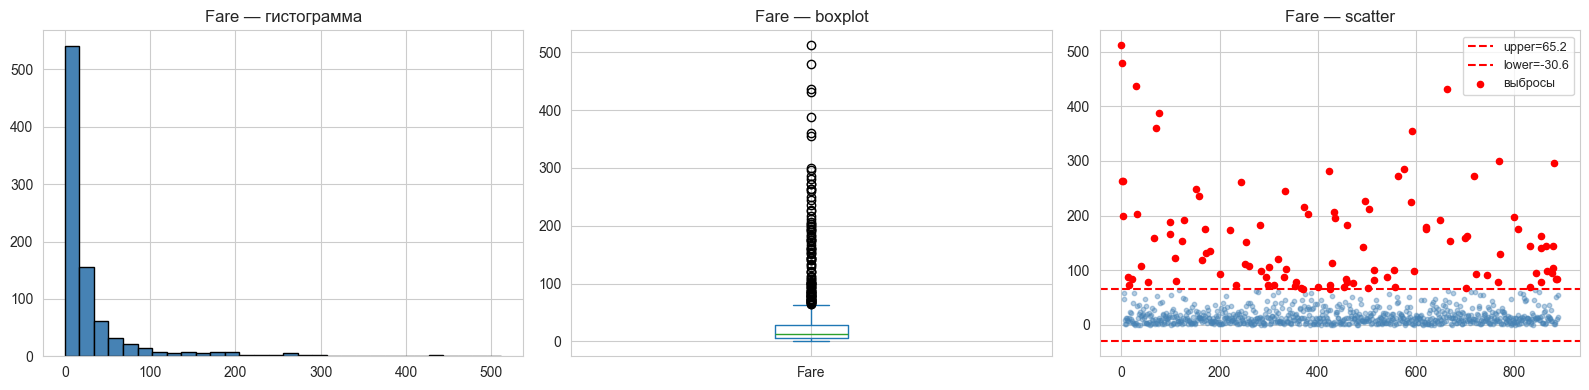


Age: нижняя граница=-1.7, верхняя граница=61.8, выбросов=8


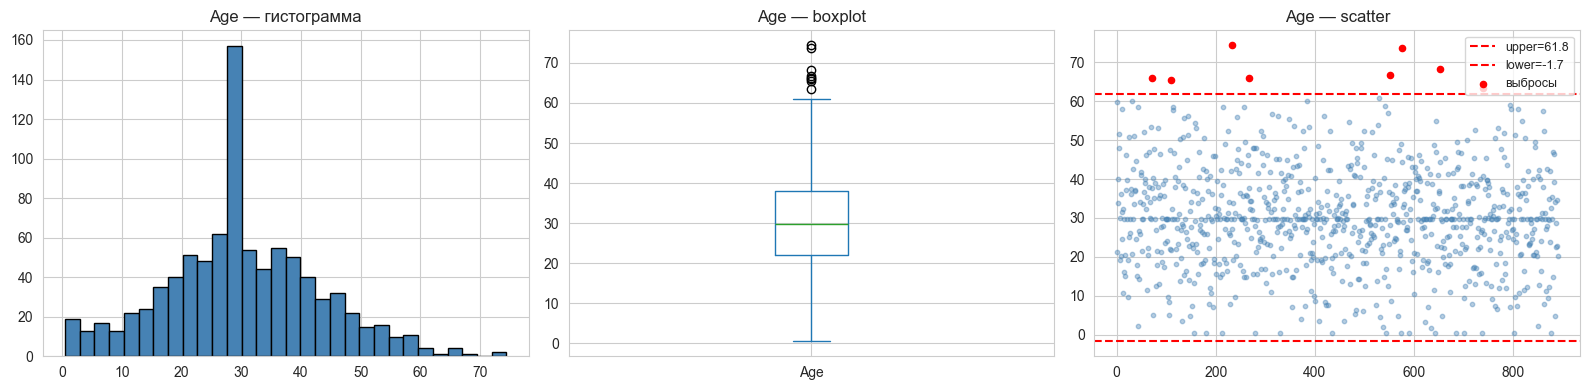


SibSp: нижняя граница=-1.5, верхняя граница=2.5, выбросов=30


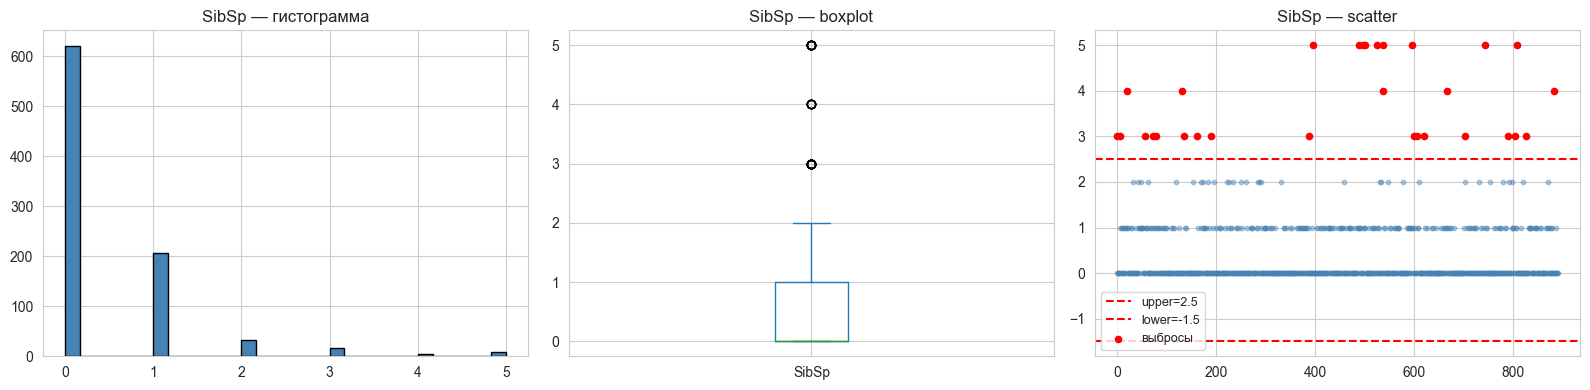

In [22]:
def detect_outliers_iqr(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    outliers_mask = (series < lower) | (series > upper)
    return lower, upper, outliers_mask

def diagnostic_outlier_plots(series, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    series.hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title(f'{title} — гистограмма')
    series.plot(kind='box', ax=axes[1])
    axes[1].set_title(f'{title} — boxplot')
    axes[2].scatter(range(len(series)), series, alpha=0.4, s=10, color='steelblue')
    lower, upper, mask = detect_outliers_iqr(series)
    axes[2].axhline(y=upper, color='red', linestyle='--', label=f'upper={upper:.1f}')
    axes[2].axhline(y=lower, color='red', linestyle='--', label=f'lower={lower:.1f}')
    axes[2].scatter(np.where(mask)[0], series[mask], color='red', s=20, label='выбросы')
    axes[2].legend(fontsize=9)
    axes[2].set_title(f'{title} — scatter')
    plt.tight_layout()
    plt.show()

outlier_cols = ['Fare', 'Age', 'SibSp']
for col in outlier_cols:
    lower, upper, mask = detect_outliers_iqr(df_imp[col])
    print(f'\n{col}: нижняя граница={lower:.1f}, верхняя граница={upper:.1f}, выбросов={mask.sum()}')
    diagnostic_outlier_plots(df_imp[col], col)

### 5.2 Удаление выбросов

Fare: удалено 106 выбросов
Age: удалено 6 выбросов
SibSp: удалено 26 выбросов

Итого: было 891 → стало 753 (удалено 138)


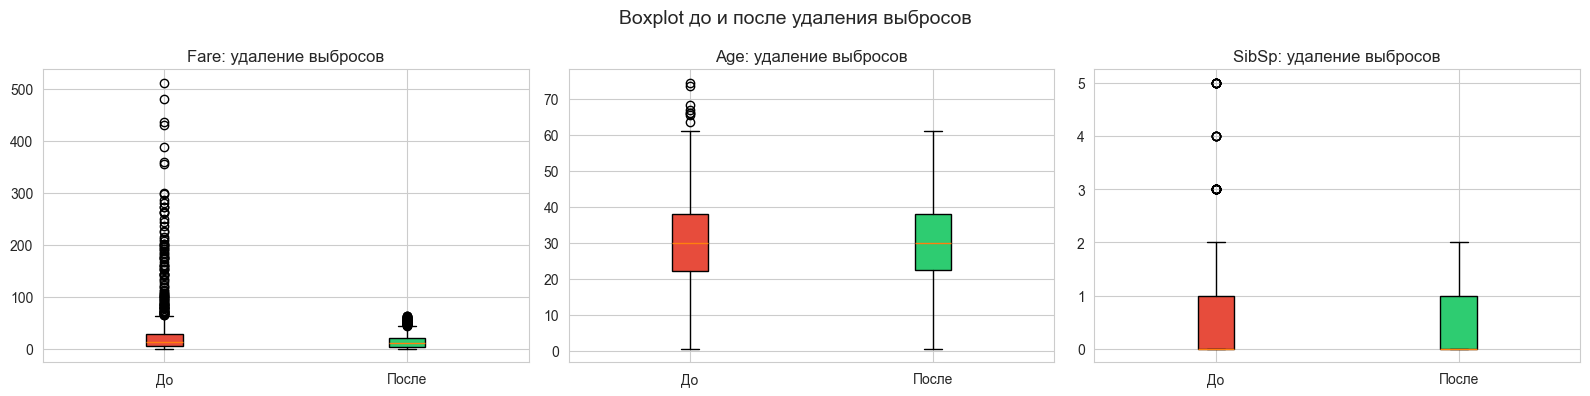

In [23]:
df_no_outliers = df_imp.copy()

total_removed = 0
for col in outlier_cols:
    lower, upper, mask = detect_outliers_iqr(df_no_outliers[col])
    n_before = len(df_no_outliers)
    df_no_outliers = df_no_outliers[~mask]
    removed = n_before - len(df_no_outliers)
    total_removed += removed
    print(f'{col}: удалено {removed} выбросов')

print(f'\nИтого: было {len(df_imp)} → стало {len(df_no_outliers)} (удалено {total_removed})')

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 4))
for ax, col in zip(axes, outlier_cols):
    bp = ax.boxplot([df_imp[col].dropna(), df_no_outliers[col].dropna()],
                    labels=['До', 'После'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#2ecc71')
    ax.set_title(f'{col}: удаление выбросов', fontsize=12)
plt.suptitle('Boxplot до и после удаления выбросов', fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 Замена выбросов (capping / winsorization)

Fare: заменено 106 выбросов (границы: [-30.6, 65.2])
Age: заменено 8 выбросов (границы: [-1.7, 61.8])
SibSp: заменено 30 выбросов (границы: [-1.5, 2.5])


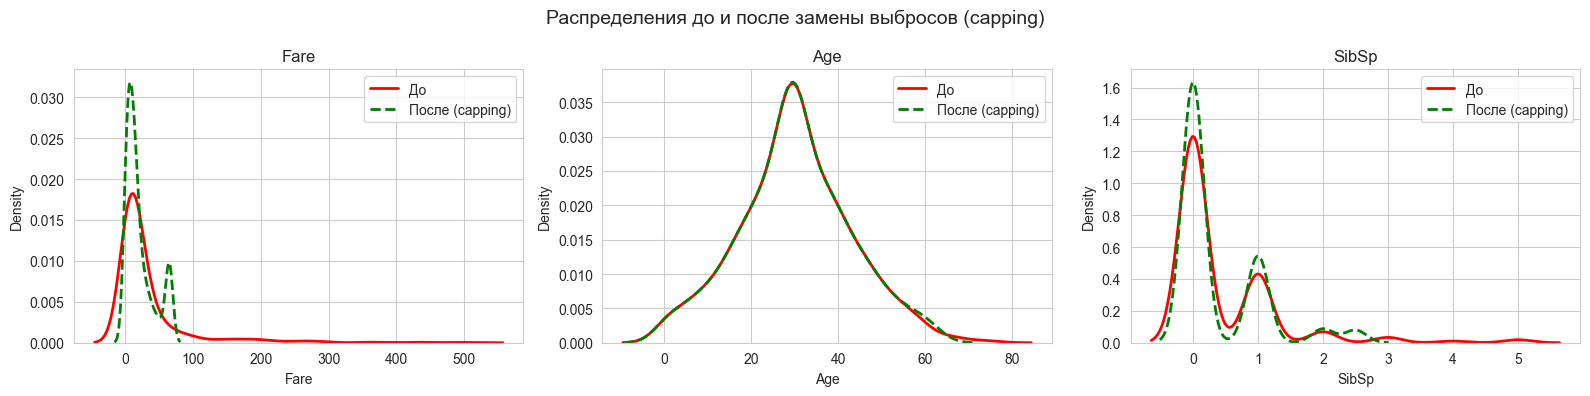


Размер данных сохранён: 891 строк (ни одна не удалена!)


In [24]:
df_capped = df_imp.copy()

for col in outlier_cols:
    lower, upper, mask = detect_outliers_iqr(df_capped[col])
    n_outliers = mask.sum()
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    print(f'{col}: заменено {n_outliers} выбросов (границы: [{lower:.1f}, {upper:.1f}])')

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 4))
for ax, col in zip(axes, outlier_cols):
    sns.kdeplot(df_imp[col], ax=ax, label='До', linewidth=2, color='red')
    sns.kdeplot(df_capped[col], ax=ax, label='После (capping)', linewidth=2,
                linestyle='--', color='green')
    ax.set_title(f'{col}', fontsize=12)
    ax.legend()
plt.suptitle('Распределения до и после замены выбросов (capping)', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nРазмер данных сохранён: {len(df_capped)} строк (ни одна не удалена!)')

---
## 6. Обработка нестандартного признака (Name → Title)

Признак `Name` содержит имя пассажира с **титулом** (Mr, Mrs, Miss, Master, Dr, Rev). Это не числовой и не простой категориальный признак — нужно извлечь смысловую информацию.

In [25]:
df_dt = df_imp.copy()
df_dt['Name'] = df['Name']  # возвращаем оригинальный Name

print(f'Тип Name: {df_dt["Name"].dtype}')
display(df_dt[['Name']].head(10))

Тип Name: object


,Name
0,"Wilson, Mr. Emma"
1,"Smith, Mr. James"
2,"Taylor, Mr. William"
3,"Brown, Mrs. Elizabeth"
4,"Davies, Mr. Robert"
5,"Taylor, Mr. Robert"
6,"Williams, Mr. Alice"
7,"Wilson, Master. William"
8,"Taylor, Mr. William"
9,"Smith, Mr. Robert"


### 6.1 Извлечение титула из имени

Распределение титулов:
Title
Mr        533
Mrs       171
Miss      128
Master     33
Dr         18
Rev         8
Name: count, dtype: int64


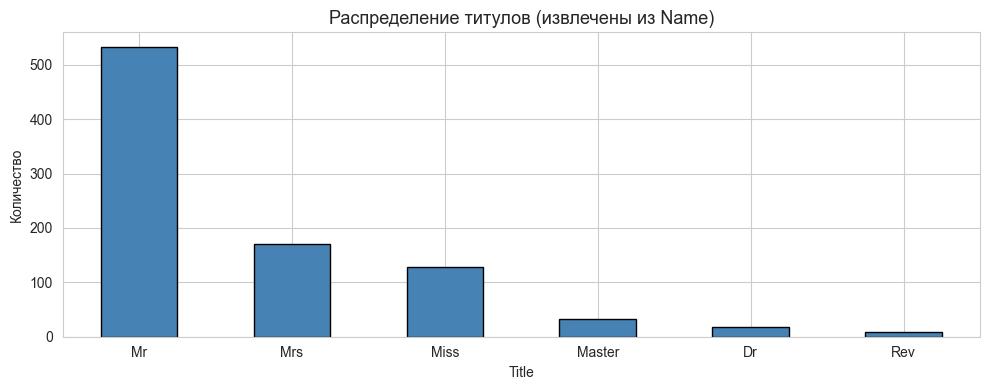

In [26]:
df_dt['Title'] = df_dt['Name'].str.extract(r',\s*(\w+)\.', expand=False)

print('Распределение титулов:')
print(df_dt['Title'].value_counts())

fig, ax = plt.subplots(figsize=(10, 4))
df_dt['Title'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Распределение титулов (извлечены из Name)', fontsize=13)
ax.set_ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.2 Группировка редких титулов

In [27]:
# Группируем редкие титулы в 'Other'
title_map = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Master': 'Master',
    'Dr': 'Other',
    'Rev': 'Other'
}
df_dt['Title_grouped'] = df_dt['Title'].map(title_map).fillna('Other')

print('Распределение после группировки:')
print(df_dt['Title_grouped'].value_counts())

Распределение после группировки:
Title_grouped
Mr        533
Mrs       171
Miss      128
Master     33
Other      26
Name: count, dtype: int64


### 6.3 Связь титула с выживаемостью

Выживаемость по титулам:


,Выживаемость,Количество
Title_grouped,,
Master,0.545455,33
Miss,0.460938,128
Mr,0.446529,533
Mrs,0.438596,171
Other,0.346154,26


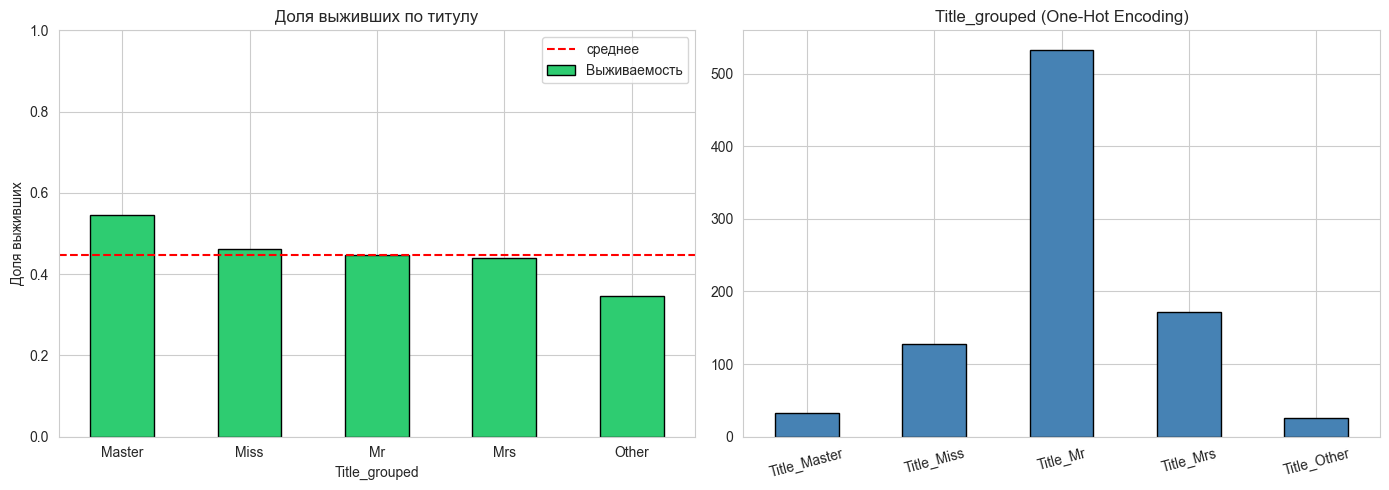


Признаки после обработки Name:


,Name,Title,Title_grouped,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other
0,"Wilson, Mr. Emma",Mr,Mr,False,False,True,False,False
1,"Smith, Mr. James",Mr,Mr,False,False,True,False,False
2,"Taylor, Mr. William",Mr,Mr,False,False,True,False,False
3,"Brown, Mrs. Elizabeth",Mrs,Mrs,False,False,False,True,False
4,"Davies, Mr. Robert",Mr,Mr,False,False,True,False,False
5,"Taylor, Mr. Robert",Mr,Mr,False,False,True,False,False
6,"Williams, Mr. Alice",Mr,Mr,False,False,True,False,False
7,"Wilson, Master. William",Master,Master,True,False,False,False,False
8,"Taylor, Mr. William",Mr,Mr,False,False,True,False,False
9,"Smith, Mr. Robert",Mr,Mr,False,False,True,False,False


In [28]:
title_survival = df_dt.groupby('Title_grouped')['Survived'].agg(['mean', 'count'])
title_survival.columns = ['Выживаемость', 'Количество']
title_survival = title_survival.sort_values('Выживаемость', ascending=False)

print('Выживаемость по титулам:')
display(title_survival)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

title_survival['Выживаемость'].plot(kind='bar', ax=axes[0], color='#2ecc71', edgecolor='black')
axes[0].set_title('Доля выживших по титулу', fontsize=12)
axes[0].set_ylabel('Доля выживших')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=df_dt['Survived'].mean(), color='red', linestyle='--', label='среднее')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# Кодируем Title_grouped через OHE для использования в модели
df_enc_title = pd.get_dummies(df_dt['Title_grouped'], prefix='Title')
df_enc_title.sum().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Title_grouped (One-Hot Encoding)', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Добавляем закодированный признак в основной датасет
df_dt = pd.concat([df_dt, df_enc_title], axis=1)

print('\nПризнаки после обработки Name:')
display(df_dt[['Name', 'Title', 'Title_grouped'] + list(df_enc_title.columns)].head(10))

---
## 7. Отбор признаков

Для отбора признаков формируем финальный датасет с закодированными признаками.

In [29]:
# Формируем финальный датасет для отбора признаков
df_final = df_imp.copy()

# Sex: label encoding (после импьютации NaN уже нет)
df_final['Sex_enc'] = (df_final['Sex'] == 'male').astype(int)

# Pclass: уже числовой

# Embarked: OHE
df_final = pd.get_dummies(df_final, columns=['Embarked'], prefix='Emb', drop_first=True)

# Cabin: извлекаем только букву палубы (A–F)
df_final['Deck'] = df_final['Cabin'].str[0]
df_final['Deck'] = df_final['Deck'].fillna('U')  # Unknown
df_final = pd.get_dummies(df_final, columns=['Deck'], prefix='Deck', drop_first=True)

# Title из Name
df_final['Title'] = df['Name'].str.extract(r',\s*(\w+)\.', expand=False)
title_map = {'Mr':'Mr','Mrs':'Mrs','Miss':'Miss','Master':'Master'}
df_final['Title_grouped'] = df_final['Title'].map(title_map).fillna('Other')
df_final = pd.get_dummies(df_final, columns=['Title_grouped'], prefix='Title', drop_first=False)

# FamilySize — новый признак
df_final['FamilySize'] = df_final['SibSp'] + df_final['Parch'] + 1
df_final['IsAlone'] = (df_final['FamilySize'] == 1).astype(int)

feature_cols = ['Pclass', 'Sex_enc', 'Age', 'Fare', 'SibSp', 'Parch',
                'FamilySize', 'IsAlone'] + \
               [c for c in df_final.columns if c.startswith('Emb_')] + \
               [c for c in df_final.columns if c.startswith('Deck_')] + \
               [c for c in df_final.columns if c.startswith('Title_')]

X_fs = df_final[feature_cols]
y_fs = df_final['Survived']

print(f'Размер: {X_fs.shape}')
print(f'Признаки: {list(X_fs.columns)}')
display(X_fs.describe().round(2))

Размер: (891, 20)
Признаки: ['Pclass', 'Sex_enc', 'Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Emb_Q', 'Emb_S', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Other']


,Pclass,Sex_enc,Age,Fare,SibSp,Parch,FamilySize,IsAlone
count,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00
mean,2.37,0.66,30.18,32.33,0.43,0.31,1.75,0.55
std,0.83,0.48,12.95,58.71,0.84,0.67,1.05,0.50
min,1.00,0.00,0.50,0.00,0.00,0.00,1.00,0.00
25%,2.00,0.00,22.10,5.33,0.00,0.00,1.00,0.00
50%,3.00,1.00,29.80,13.23,0.00,0.00,1.00,1.00
75%,3.00,1.00,38.00,29.28,1.00,0.00,2.00,1.00
max,3.00,1.00,74.40,512.00,5.00,3.00,8.00,1.00


### 7.1 Filter method — SelectKBest (mutual information)

SelectKBest (mutual information, k=8):
Отобранные признаки: ['Fare', 'Title_Other', 'Pclass', 'Title_Miss', 'Title_Master', 'Deck_D', 'FamilySize', 'Emb_Q']


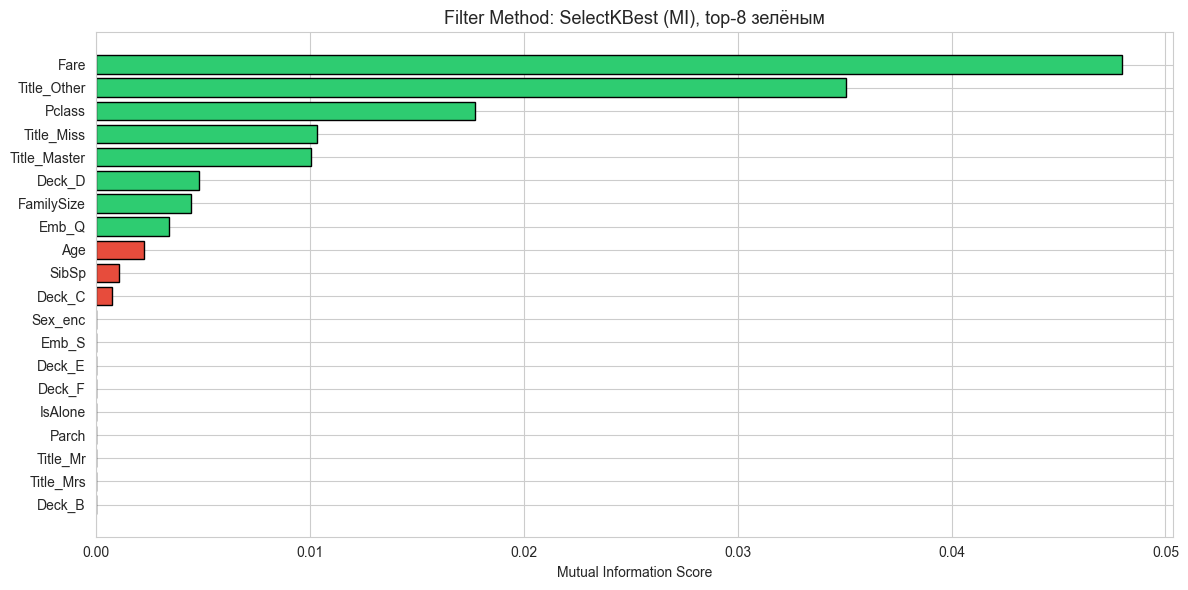

In [30]:
k_best = 8
selector_filter = SelectKBest(score_func=mutual_info_classif, k=k_best)
selector_filter.fit(X_fs, y_fs)

mi_scores = pd.DataFrame({
    'Признак': feature_cols,
    'MI Score': selector_filter.scores_,
    'Отобран': selector_filter.get_support()
}).sort_values('MI Score', ascending=False)

print(f'SelectKBest (mutual information, k={k_best}):')
print(f'Отобранные признаки: {list(mi_scores[mi_scores["Отобран"]]["Признак"])}')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if s else '#e74c3c' for s in mi_scores['Отобран']]
ax.barh(mi_scores['Признак'], mi_scores['MI Score'], color=colors, edgecolor='black')
ax.set_xlabel('Mutual Information Score')
ax.set_title(f'Filter Method: SelectKBest (MI), top-{k_best} зелёным', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 7.2 Wrapper method — RFE (Recursive Feature Elimination)

RFE (Recursive Feature Elimination) с LogisticRegression:
Отобранные признаки: ['Pclass', 'Title_Master', 'IsAlone', 'FamilySize', 'Parch', 'Title_Other', 'Age', 'Sex_enc']


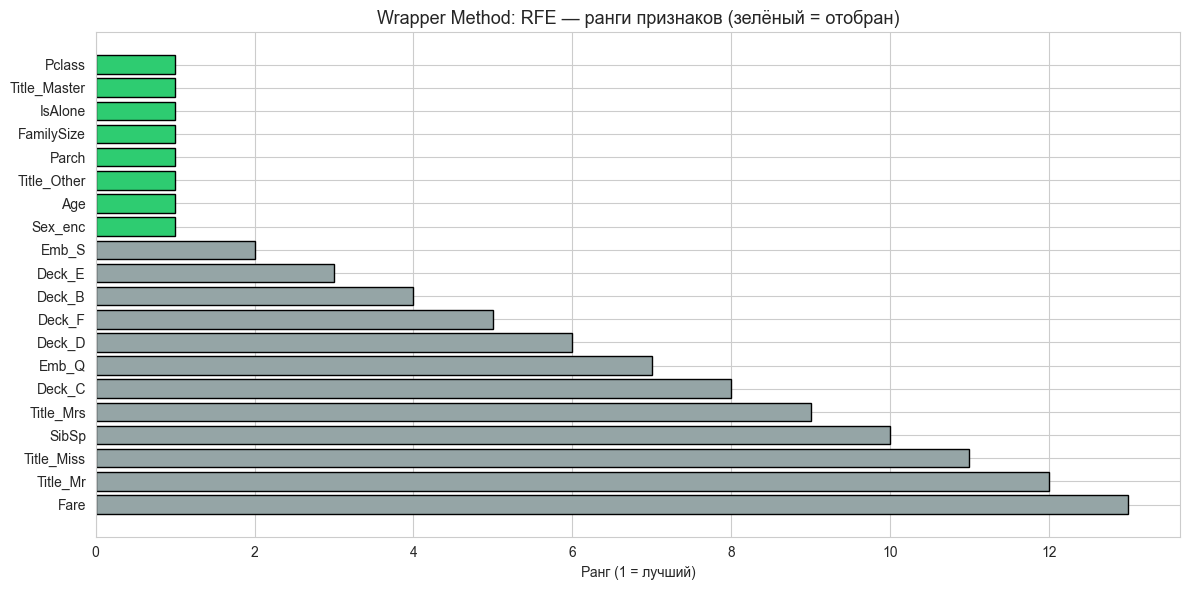

In [31]:
estimator_rfe = LogisticRegression(max_iter=5000, random_state=42)
rfe_selector = RFE(estimator=estimator_rfe, n_features_to_select=8, step=1)

scaler_rfe = StandardScaler()
X_fs_scaled = scaler_rfe.fit_transform(X_fs)
rfe_selector.fit(X_fs_scaled, y_fs)

rfe_results = pd.DataFrame({
    'Признак': feature_cols,
    'Ранг': rfe_selector.ranking_,
    'Отобран': rfe_selector.support_
}).sort_values('Ранг')

print('RFE (Recursive Feature Elimination) с LogisticRegression:')
print(f'Отобранные признаки: {list(rfe_results[rfe_results["Отобран"]]["Признак"])}')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if s else '#95a5a6' for s in rfe_results['Отобран']]
ax.barh(rfe_results['Признак'], rfe_results['Ранг'], color=colors, edgecolor='black')
ax.set_xlabel('Ранг (1 = лучший)')
ax.set_title('Wrapper Method: RFE — ранги признаков (зелёный = отобран)', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 7.3 Embedded method — SelectFromModel (Random Forest)

Embedded: SelectFromModel (RandomForest):
Порог: mean importance = 0.0500
Отобранные признаки: ['Fare', 'Age', 'Pclass']


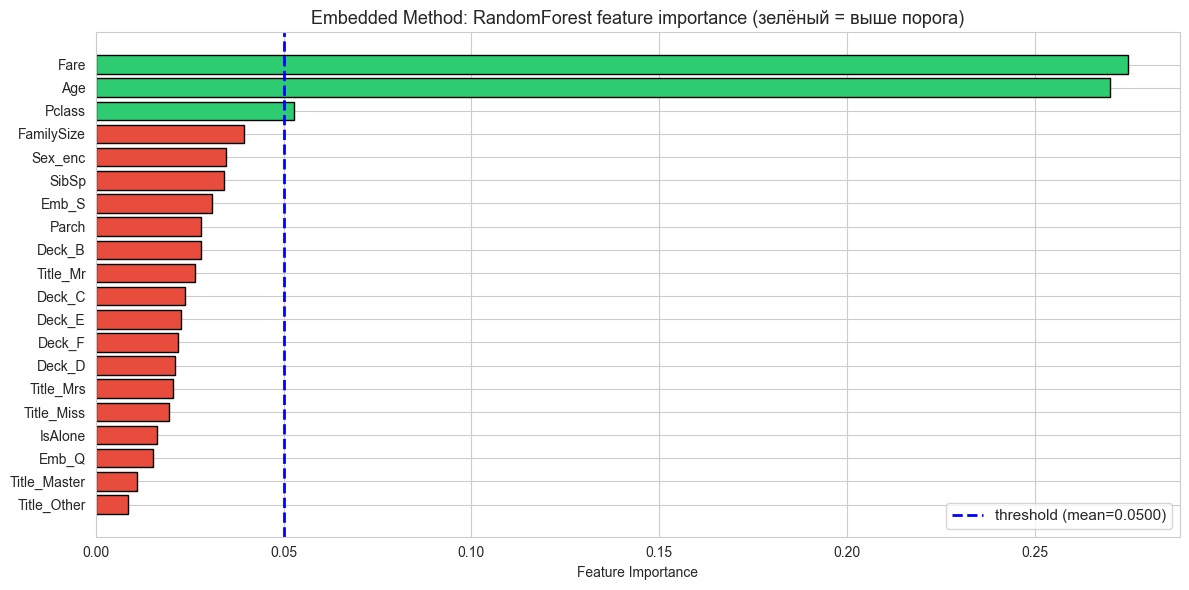

In [32]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_fs, y_fs)

embedded_selector = SelectFromModel(rf, prefit=True)
selected_mask = embedded_selector.get_support()

emb_results = pd.DataFrame({
    'Признак': feature_cols,
    'Важность': rf.feature_importances_,
    'Отобран': selected_mask
}).sort_values('Важность', ascending=False)

print('Embedded: SelectFromModel (RandomForest):')
print(f'Порог: mean importance = {rf.feature_importances_.mean():.4f}')
print(f'Отобранные признаки: {list(emb_results[emb_results["Отобран"]]["Признак"])}')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if s else '#e74c3c' for s in emb_results['Отобран']]
ax.barh(emb_results['Признак'], emb_results['Важность'], color=colors, edgecolor='black')
ax.axvline(x=rf.feature_importances_.mean(), color='blue', linestyle='--',
           linewidth=2, label=f'threshold (mean={rf.feature_importances_.mean():.4f})')
ax.set_xlabel('Feature Importance')
ax.set_title('Embedded Method: RandomForest feature importance (зелёный = выше порога)', fontsize=13)
ax.legend(fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 7.4 Сравнение трёх методов отбора

In [33]:
comparison = pd.DataFrame({
    'Признак': feature_cols,
    'Filter (MI)': selector_filter.get_support(),
    'Wrapper (RFE)': rfe_selector.support_,
    'Embedded (RF)': selected_mask
})
comparison['Сумма методов'] = (comparison['Filter (MI)'].astype(int) +
                                comparison['Wrapper (RFE)'].astype(int) +
                                comparison['Embedded (RF)'].astype(int))
comparison = comparison.sort_values('Сумма методов', ascending=False)

print('Сравнение методов отбора (True = признак отобран):')
display(comparison.style.map(
    lambda v: 'background-color: #d4edda' if v == True else
              ('background-color: #f8d7da' if v == False else ''),
    subset=['Filter (MI)', 'Wrapper (RFE)', 'Embedded (RF)']
))

Сравнение методов отбора (True = признак отобран):


,Признак,Filter (MI),Wrapper (RFE),Embedded (RF),Сумма методов
0,Pclass,True,True,True,3
6,FamilySize,True,True,False,2
15,Title_Master,True,True,False,2
19,Title_Other,True,True,False,2
3,Fare,True,False,True,2
2,Age,False,True,True,2
5,Parch,False,True,False,1
7,IsAlone,False,True,False,1
8,Emb_Q,True,False,False,1
1,Sex_enc,False,True,False,1


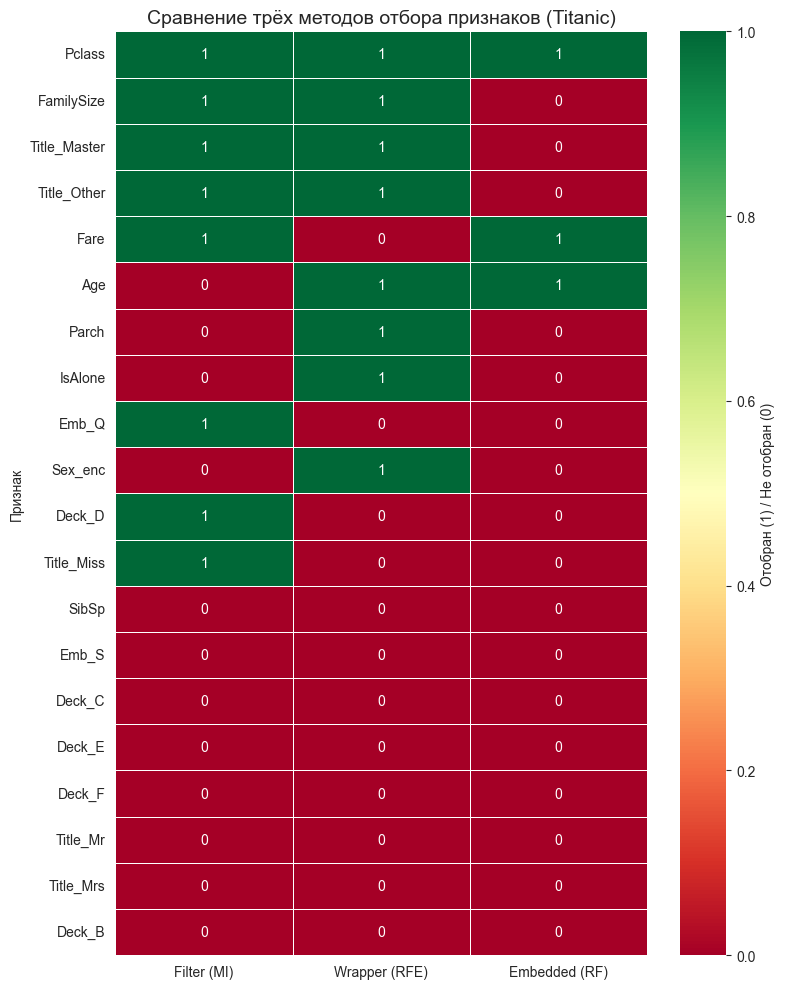

In [34]:
heat_data = comparison.set_index('Признак')[['Filter (MI)', 'Wrapper (RFE)', 'Embedded (RF)']].astype(int)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(heat_data, annot=True, cmap='RdYlGn', linewidths=0.5,
            cbar_kws={'label': 'Отобран (1) / Не отобран (0)'}, ax=ax, fmt='d')
ax.set_title('Сравнение трёх методов отбора признаков (Titanic)', fontsize=14)
plt.tight_layout()
plt.show()

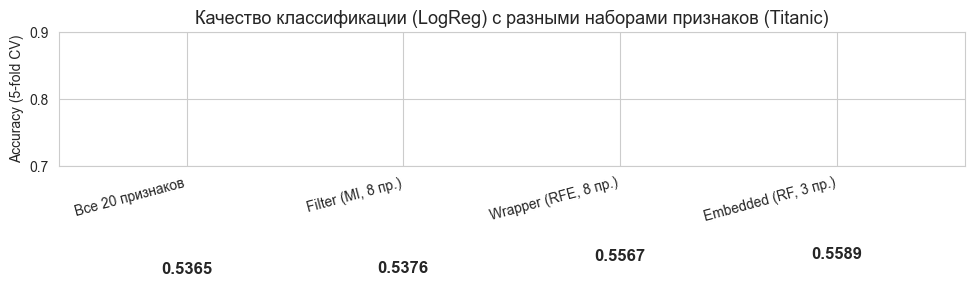

Результаты (accuracy):
  Все 20 признаков: 0.5365
  Filter (MI, 8 пр.): 0.5376
  Wrapper (RFE, 8 пр.): 0.5567
  Embedded (RF, 3 пр.): 0.5589


In [35]:
clf = LogisticRegression(max_iter=5000, random_state=42)
scaler = StandardScaler()

results_cv = {}

X_all_sc = scaler.fit_transform(X_fs)
scores_all = cross_val_score(clf, X_all_sc, y_fs, cv=5, scoring='accuracy')
results_cv[f'Все {X_fs.shape[1]} признаков'] = scores_all.mean()

X_filter = X_fs.iloc[:, selector_filter.get_support()]
scores_filter = cross_val_score(clf, scaler.fit_transform(X_filter), y_fs, cv=5, scoring='accuracy')
results_cv[f'Filter (MI, {X_filter.shape[1]} пр.)'] = scores_filter.mean()

X_wrapper = X_fs.iloc[:, rfe_selector.support_]
scores_wrapper = cross_val_score(clf, scaler.fit_transform(X_wrapper), y_fs, cv=5, scoring='accuracy')
results_cv[f'Wrapper (RFE, {X_wrapper.shape[1]} пр.)'] = scores_wrapper.mean()

X_embedded = X_fs.iloc[:, selected_mask]
scores_embedded = cross_val_score(clf, scaler.fit_transform(X_embedded), y_fs, cv=5, scoring='accuracy')
results_cv[f'Embedded (RF, {X_embedded.shape[1]} пр.)'] = scores_embedded.mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax.bar(results_cv.keys(), results_cv.values(), color=colors_bar, edgecolor='black')
for bar, val in zip(bars, results_cv.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Качество классификации (LogReg) с разными наборами признаков (Titanic)', fontsize=13)
ax.set_ylim(0.7, 0.9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print('Результаты (accuracy):')
for k, v in results_cv.items():
    print(f'  {k}: {v:.4f}')

---
## Итоги

| Задача | Что сделано | Особенности (Titanic) |
|--------|------------|----------------------|
| 1. Пропуски | Удаление строк, медиана (Age, Fare, SibSp, Parch, Pclass), KNN, мода (Sex, Embarked, Cabin) | 8 признаков с пропусками 5–14% — равномерное распределение |
| 2. Кодирование | Label (Sex), Ordinal (Pclass), One-Hot (Embarked) | Sex — бинарный; Pclass имеет порядок |
| 3. Нормализация | Log, Sqrt, Box-Cox, Yeo-Johnson для Fare | Fare — экспоненциальное распределение с выбросами |
| 4. Масштабирование | StandardScaler, MinMaxScaler, RobustScaler | Fare чувствителен к выбросам → RobustScaler предпочтителен |
| 5. Выбросы | Обнаружение (IQR), удаление, замена (capping) | Fare: крупные выбросы у пассажиров 1-го класса |
| 6. Нестандартный признак | Name → Title → Title_grouped → One-Hot | Извлечение социального статуса; Mrs/Miss выживают чаще |
| 7. Отбор признаков | Filter (SelectKBest+MI), Wrapper (RFE), Embedded (RF) | Sex, Fare, Title, Deck наиболее информативны |